Training for 0 iterations...


<Figure size 1000x800 with 0 Axes>

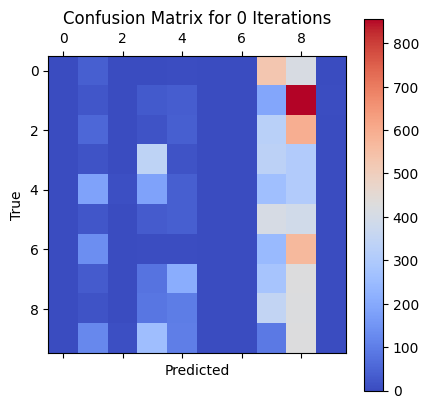

Training for 1 iterations...
Iteration 0, Loss: 2.2929


<Figure size 1000x800 with 0 Axes>

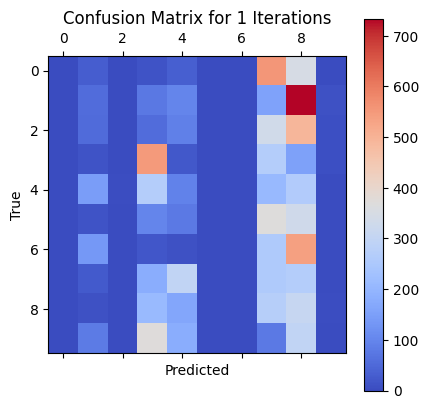

Training for 10 iterations...
Iteration 0, Loss: 2.2818
Iteration 1, Loss: 2.2735
Iteration 2, Loss: 2.2900
Iteration 3, Loss: 2.2653
Iteration 4, Loss: 2.2940
Iteration 5, Loss: 2.2757
Iteration 6, Loss: 2.2670
Iteration 7, Loss: 2.2526
Iteration 8, Loss: 2.2758
Iteration 9, Loss: 2.2771


<Figure size 1000x800 with 0 Axes>

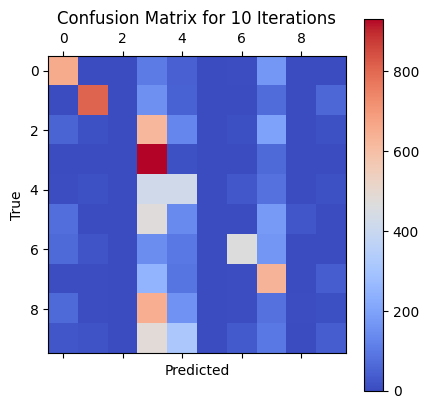

Training for 100 iterations...
Iteration 0, Loss: 2.2179
Iteration 10, Loss: 2.1889
Iteration 20, Loss: 2.1382
Iteration 30, Loss: 2.0480
Iteration 40, Loss: 1.9283
Iteration 50, Loss: 1.8155
Iteration 60, Loss: 1.5937
Iteration 70, Loss: 1.3839
Iteration 80, Loss: 1.3561
Iteration 90, Loss: 1.2446


<Figure size 1000x800 with 0 Axes>

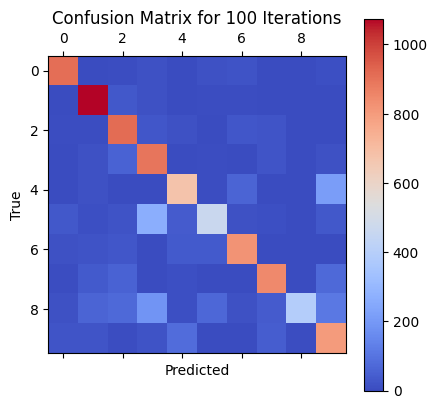

Training for 1000 iterations...
Iteration 0, Loss: 0.9978
Iteration 100, Loss: 0.4653
Iteration 200, Loss: 0.2922
Iteration 300, Loss: 0.3460
Iteration 400, Loss: 0.2190
Iteration 500, Loss: 0.2644
Iteration 600, Loss: 0.1210
Iteration 700, Loss: 0.3150
Iteration 800, Loss: 0.2388
Iteration 900, Loss: 0.2915


<Figure size 1000x800 with 0 Axes>

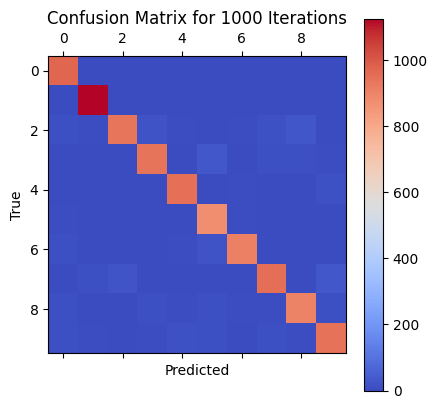

Training for 10000 iterations...
Iteration 0, Loss: 0.1744


<Figure size 1000x800 with 0 Axes>

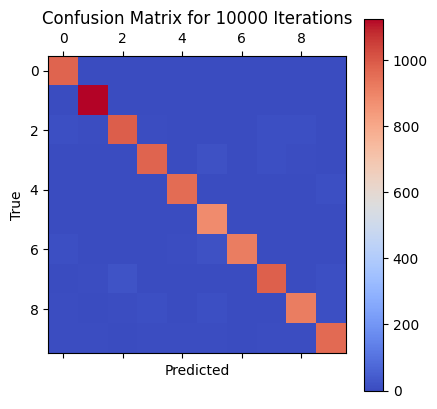

   num_iterations  test_accuracy  time_taken      loss
0               0      11.050000    0.623131  0.045095
1               1      12.650000    2.111863  2.292950
2              10      39.570001    1.039815  2.277108
3             100      77.920002    8.970680  1.021449
4            1000      94.900000   75.679503  0.058969
5           10000      96.899998   72.573689  0.031970


In [8]:
import pandas as pd
import tensorflow as tf
import numpy as np
import time
from datetime import timedelta
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Convolutional Layer Parameters
filter_size1 = 5
num_filters1 = 16
filter_size2 = 5
num_filters2 = 36

# Fully-connected layer size
fc_size = 128
num_classes = 10

# Load and preprocess MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize

# Reshape data and one-hot encode labels
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

# Create TensorFlow Dataset objects
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(256)

# Define CNN Model
class CNNModel(tf.keras.Model):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = tf.keras.layers.Conv2D(filters=num_filters1, kernel_size=filter_size1, padding='same', activation='relu')
        self.pool1 = tf.keras.layers.MaxPooling2D(pool_size=2, strides=2, padding='same')
        self.conv2 = tf.keras.layers.Conv2D(filters=num_filters2, kernel_size=filter_size2, padding='same', activation='relu')
        self.pool2 = tf.keras.layers.MaxPooling2D(pool_size=2, strides=2, padding='same')
        self.flatten = tf.keras.layers.Flatten()
        self.fc1 = tf.keras.layers.Dense(fc_size, activation='relu')
        self.fc2 = tf.keras.layers.Dense(num_classes, activation='softmax')

    def call(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

model = CNNModel()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
loss_fn = tf.keras.losses.CategoricalCrossentropy()

# Training function
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        predictions = model(images)
        loss = loss_fn(labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

# Evaluation function
def evaluate(dataset):
    accuracy = tf.keras.metrics.CategoricalAccuracy()
    predictions_list = []
    labels_list = []
    for images, labels in dataset:
        predictions = model(images, training=False)
        accuracy.update_state(labels, predictions)

        # Collect predictions and true labels for confusion matrix
        predictions_list.append(predictions.numpy())
        labels_list.append(labels.numpy())

    # Concatenate the list of predictions and labels
    predictions = np.concatenate(predictions_list)
    labels = np.concatenate(labels_list)

    return accuracy.result().numpy(), predictions, labels

# Results storage list
results = []

# Array of num_iterations to test
num_iterations_array = [0, 1, 10, 100, 1000, 10000]

# Training loop with different iteration counts
for num_iterations in num_iterations_array:
    start_time = time.time()
    print(f"Training for {num_iterations} iterations...")

    # Train for 'num_iterations'
    for iteration, (images, labels) in enumerate(train_ds.take(num_iterations)):
        loss = train_step(images, labels)
        if iteration % (num_iterations/10) == 0:
            print(f"Iteration {iteration}, Loss: {loss.numpy():.4f}")

    # Calculate the time taken and test accuracy
    end_time = time.time()
    test_accuracy, predictions, labels = evaluate(test_ds)

    # Generate confusion matrix
    cm = confusion_matrix(np.argmax(labels, axis=1), np.argmax(predictions, axis=1))

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    plt.matshow(cm, cmap='coolwarm')
    plt.colorbar()
    plt.title(f"Confusion Matrix for {num_iterations} Iterations")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Store the results for the current number of iterations
    elapsed_time = end_time - start_time
    results.append({
        'num_iterations': num_iterations,
        'test_accuracy': test_accuracy * 100,  # Convert accuracy to percentage
        'time_taken': elapsed_time,
        'loss': loss.numpy()
    })

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Print out the results
print(df_results)


In [9]:
df_results

,num_iterations,test_accuracy,time_taken,loss
0,0,11.050000,0.623131,0.045095
1,1,12.650000,2.111863,2.292950
2,10,39.570001,1.039815,2.277108
3,100,77.920002,8.970680,1.021449
4,1000,94.900000,75.679503,0.058969
5,10000,96.899998,72.573689,0.031970


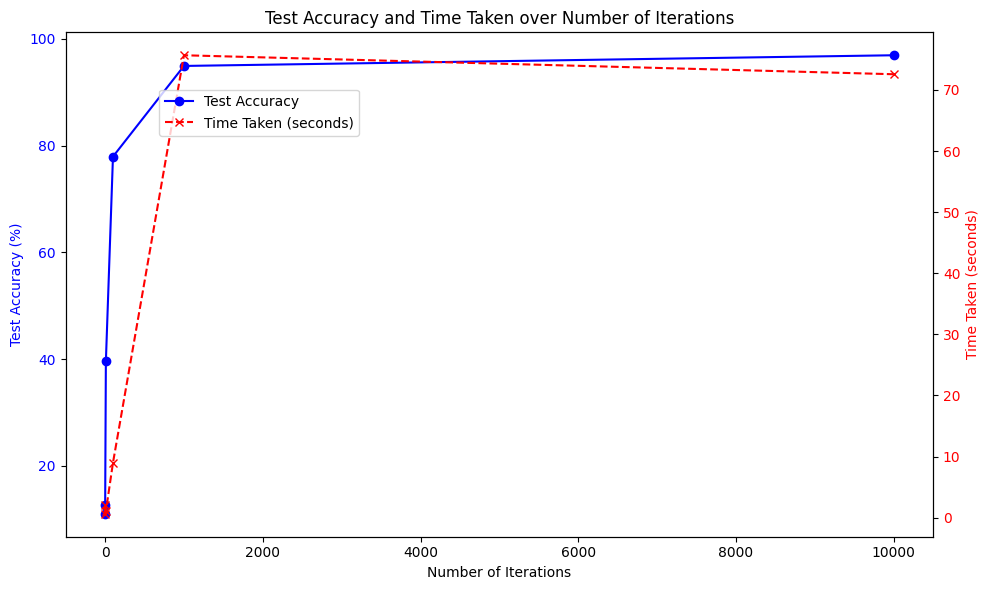

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = {
    'num_iterations': [0, 1, 10, 100, 1000, 10000],
    'test_accuracy': [11.05, 12.65, 39.57, 77.92, 94.9, 96.9],
    'time_taken': [0.623131, 2.111863, 1.039815, 8.97068, 75.679503, 72.573689]
}
df = pd.DataFrame(data)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Line plot for Test Accuracy
ax1.plot(df['num_iterations'], df['test_accuracy'], color='blue', marker='o', label='Test Accuracy')
ax1.set_xlabel('Number of Iterations')
ax1.set_ylabel('Test Accuracy (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Time Taken
ax2 = ax1.twinx()
ax2.plot(df['num_iterations'], df['time_taken'], color='red', marker='x', linestyle='--', label='Time Taken (seconds)')
ax2.set_ylabel('Time Taken (seconds)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Adding Legends
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9), bbox_transform=ax1.transAxes)

# Title
plt.title('Test Accuracy and Time Taken over Number of Iterations')

# Show plot
plt.tight_layout()
plt.show()
